データサイエンス特別PG データサイエンス特論 第8回 iris(setona)の重回帰分析

In [ ]:
# google colab で実行する場合は下の行のコメントアウトを外して、wget を実行
# ! wget https://raw.githubusercontent.com/KHiraGit/sudspg_ds/main/iris_setosa.xlsx

In [1]:
import pandas as pd
import openpyxl
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import statsmodels.api as sm

# CSVデータをデータテーブルに読み込む
df = pd.read_excel('iris_setosa.xlsx')
x = df.loc[:, ['sepal_width', 'petal_length', 'petal_width']].values
y = df.loc[:, ['sepal_length']].values
x_added_constant = sm.add_constant(x)  # 回帰計算のために定数項の列を追加

# モデルを推定し、結果を出力
model = sm.OLS(y, x_added_constant)
result = model.fit()
print('### ALL ###')
print (result.summary())

### ALL ###
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     20.92
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.07e-08
Time:                        09:41:59   Log-Likelihood:                 3.2094
No. Observations:                  50   AIC:                             1.581
Df Residuals:                      46   BIC:                             9.229
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3454      0.392      5.

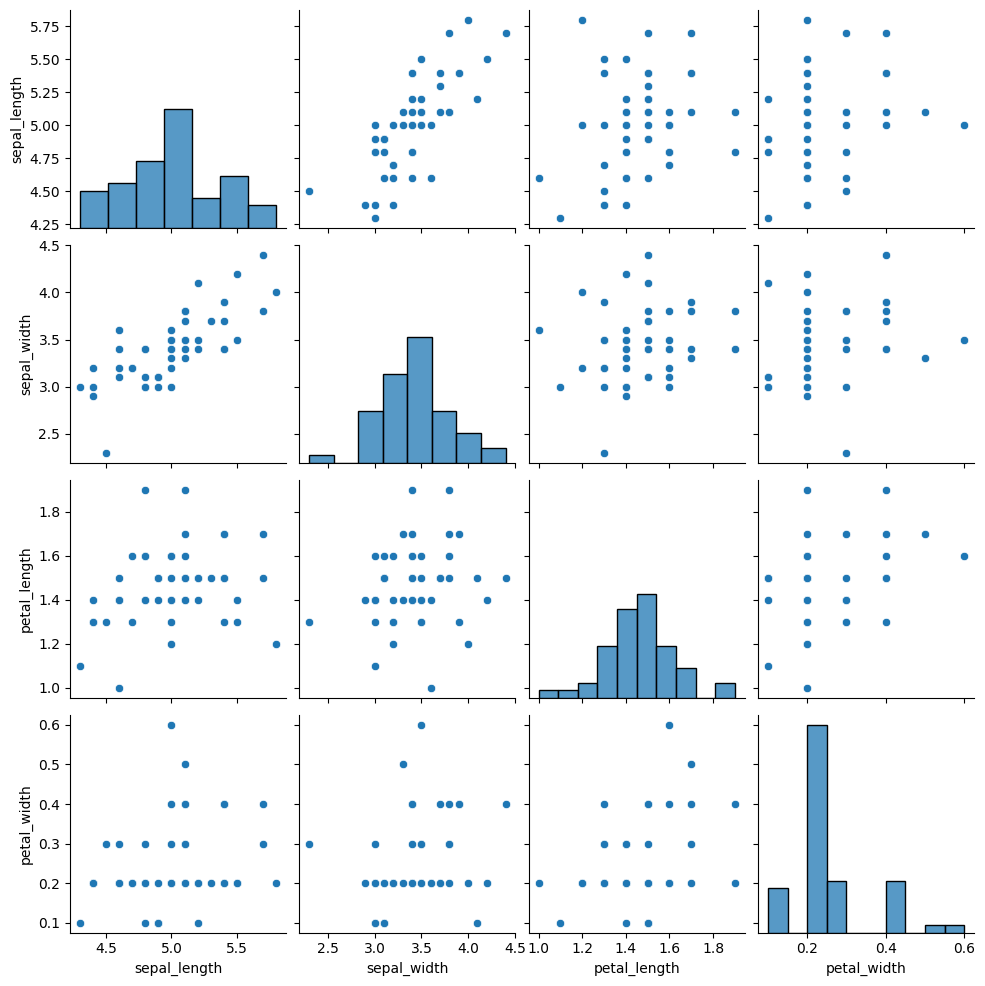

In [ ]:
# iris setosa データのペアプロットを表示
sns.pairplot(df)

<Axes: >

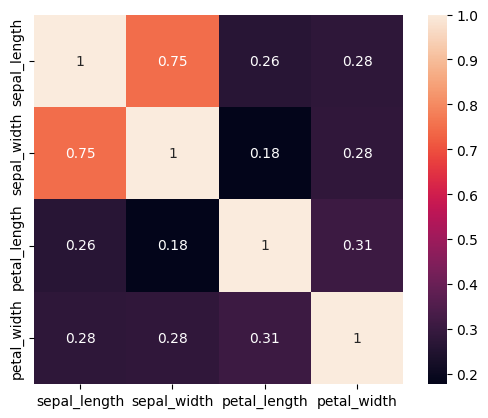

In [3]:
# 相関行列を作成して、ヒートマップを表示
df_corr = df.loc[:, ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].corr()
sns.heatmap(df_corr, square=True, annot=True)

In [7]:
# iris_setosaデータを独立変数の選択を行い、それぞれ重回帰分析を実施

for _x in [['sepal_width', 'petal_length', 'petal_width'], ['sepal_width', 'petal_length'], ['sepal_width', 'petal_width'], ['petal_length', 'petal_width'], ['sepal_width'], ['petal_length'], ['petal_width']]:

    x = df.loc[:, _x].values
    y = df.loc[:, ['sepal_length']].values
    x_added_constant = sm.add_constant(x)  # 回帰計算のために定数項の列を追加

    # モデルを推定し、結果を出力
    model = sm.OLS(y, x_added_constant)
    result = model.fit()
    print(f'### sepal_length and {_x} ###')
    print (result.summary())

### sepal_length and ['sepal_width', 'petal_length', 'petal_width'] ###
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     20.92
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.07e-08
Time:                        09:53:37   Log-Likelihood:                 3.2094
No. Observations:                  50   AIC:                             1.581
Df Residuals:                      46   BIC:                             9.229
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [9]:
# 独立変数間の分散拡大要因を確認
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

# 変数を準備
x = df.loc[:, ['sepal_width', 'petal_length', 'petal_width']].values
y = df.loc[:, ['sepal_length']].values
x_added_constant = sm.add_constant(x)  # 回帰計算のために定数項の列を追加

# モデルを推定し、結果を出力
model = sm.OLS(y, x_added_constant)
result = model.fit()
num_cols = model.exog.shape[1] # 説明変数の列数
vifs = [vif(model.exog, i) for i in range(0, num_cols)]
print(pd.DataFrame(vifs, index=model.exog_names, columns=['VIF']))

              VIF
const  137.606994
x1       1.095903
x2       1.114576
x3       1.171614
